# Phase 6: Business Impact

**Goal:** Translate X-Learner's ranking advantage into concrete business numbers, asking how much more incremental value does uplift targeting generate vs random targeting, and what is the profit-maximizing policy given a cost and value assumption?

X-Learner is used as the primary model based on Phase 4 results (Qini AUC 0.0853 vs T-Learner's 0.0581) and Phase 5 bootstrap validation (non-overlapping 95% CIs).

**Input:** `data/scores_combined.parquet`  
**Outputs:** `images/budget_simulation.png`, `images/profit_curve.png`, `images/sensitivity_analysis.png`

## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_theme(style="whitegrid", palette="muted")
pd.set_option("display.max_columns", None)

## 2. Load Scores

Load the combined score file from phase 5. It contains `y_true`, `treatment`, `uplift_t`, and `uplift_x` for the 1.4M test users. Only X-Learner scores are used here based on its superior Qini AUC.

In [2]:
df = pd.read_parquet("../data/scores_combined.parquet")
print("Shape:", df.shape)
df.head()

Shape: (1397960, 4)


,y_true,treatment,uplift_t,uplift_x
0,0,1,-0.017954,0.116142
1,0,0,0.003411,0.008847
2,0,0,0.000720,0.008825
3,0,1,-0.002254,0.332980
4,0,1,0.007887,0.203215


## 3. Budget Simulation

At each budget level f, the top `k = f × N` users are selected by predicted uplift score. Within that group, `uplift_rate = rate_t_topk - rate_c_topk` is computed using within-k counts, consistent with sklift's Qini implementation.

Two scales are reported:
- **Qini scale** (`n_t_topk × uplift_rate`): incremental visits among treated users in top-k. Scoped to the treated portion of the targeted group.
- **AUUC scale** (`k × uplift_rate`): incremental visits extrapolated to all k targeted users. Treats the within-k uplift rate as if applied to the full targeted group regardless of treatment assignment.

In [3]:
df_sorted = df.sort_values("uplift_x", ascending=False).reset_index(drop=True)

N = len(df_sorted)
N_t_all = int((df_sorted["treatment"] == 1).sum())
N_c_all = int((df_sorted["treatment"] == 0).sum())

visits_t_all = df_sorted.loc[df_sorted["treatment"] == 1, "y_true"].sum()
visits_c_all = df_sorted.loc[df_sorted["treatment"] == 0, "y_true"].sum()
rate_t_all = visits_t_all / N_t_all
rate_c_all = visits_c_all / N_c_all

total_incremental_qini = visits_t_all - visits_c_all * (N_t_all / N_c_all)
total_incremental_auuc = N * (rate_t_all - rate_c_all)

print(f"Ceiling (Qini scale, treated users only): {total_incremental_qini:.0f}")
print(f"Ceiling (AUUC scale, all users treated):  {total_incremental_auuc:.0f}")

budget_levels = np.arange(0.01, 1.01, 0.01)
rows = []

for f in budget_levels:
    k = int(f * N)
    top_k = df_sorted.iloc[:k]

    n_t_topk = int((top_k["treatment"] == 1).sum())
    n_c_topk = k - n_t_topk

    if n_t_topk == 0 or n_c_topk == 0:  # guard for very small k
        continue

    visits_t = top_k.loc[top_k["treatment"] == 1, "y_true"].sum()
    visits_c = top_k.loc[top_k["treatment"] == 0, "y_true"].sum()

    rate_t = visits_t / n_t_topk
    rate_c = visits_c / n_c_topk
    uplift_rate = rate_t - rate_c

    incremental_qini = n_t_topk * uplift_rate
    incremental_auuc = k * uplift_rate
    random_qini      = f * total_incremental_qini
    random_auuc      = f * total_incremental_auuc

    rows.append({
        "fraction_targeted": round(f, 2),
        "n_targeted":        k,
        "trmnt_ratio_topk":  n_t_topk / k,
        "uplift_rate_topk":  uplift_rate,
        "incremental_qini":  incremental_qini,
        "incremental_auuc":  incremental_auuc,
        "random_qini":       random_qini,
        "random_auuc":       random_auuc,
    })

results = pd.DataFrame(rows)
results.head(10)

Ceiling (Qini scale, treated users only): 12287
Ceiling (AUUC scale, all users treated):  14456


,fraction_targeted,n_targeted,trmnt_ratio_topk,uplift_rate_topk,incremental_qini,incremental_auuc,random_qini,random_auuc
0,0.01,13979,0.892052,0.118202,1473.974818,1652.341137,122.873333,144.556863
1,0.02,27959,0.883794,0.106724,2637.161896,2983.909731,245.746667,289.113725
2,0.03,41938,0.877867,0.093736,3451.000000,3931.117938,368.620000,433.670588
3,0.04,55918,0.872385,0.088459,4315.205437,4946.448642,491.493333,578.227451
4,0.05,69898,0.869338,0.080429,4887.290047,5621.851390,614.366667,722.784314
5,0.06,83877,0.866113,0.071899,5223.221371,6030.643233,737.240000,867.341176
6,0.07,97857,0.863760,0.064054,5414.160441,6268.127752,860.113333,1011.898039
7,0.08,111836,0.861842,0.057825,5573.492201,6466.951017,982.986667,1156.454902
8,0.09,125816,0.860765,0.053870,5833.991780,6777.682965,1105.860000,1301.011765
9,0.10,139796,0.859066,0.049911,5994.041722,6977.393180,1228.733333,1445.568627


- **Treatment ratio in top-k**: starts at 89.2% at 1% budget, converging toward the global 85% as budget expands. Top-ranked users are slightly enriched for treated users.

- **Diminishing returns**: `uplift_rate_topk` drops from 11.8% at top 1% to 5.0% at top 10%. The most persuadable users are concentrated at the top.

- **Uplift vs random (Qini scale)**: at 1% budget, uplift targeting generates 1,474 incremental visits vs 123 for random (~12x). At 10%, the gap narrows to 5,994 vs 1,229 (~4.9x). Uplift targeting captures 12% of the Qini ceiling at 1% budget; random captures only 1%.

- **AUUC scale vs Qini scale**: AUUC scale is consistently higher by a factor of 1 / trmnt_ratio_topk (~1.12 at 1% budget), since it assumes all k targeted users receive the ad rather than just the treated fraction.

- **Non-monotonicity**: local dips can appear at points where within-k uplift rate variance dominates, reflecting sleeping dogs ranked too high or sure things with near-zero uplift. These local fluctuations are smoothed out in the Qini AUC.

## 4. Visualization

Two panels:
- Left: incremental visits vs fraction targeted (Qini scale and AUUC scale, each vs their random baseline)
- Right: uplift rate within top-k vs fraction targeted, showing how the incremental rate decays as budget expands to lower-uplift users

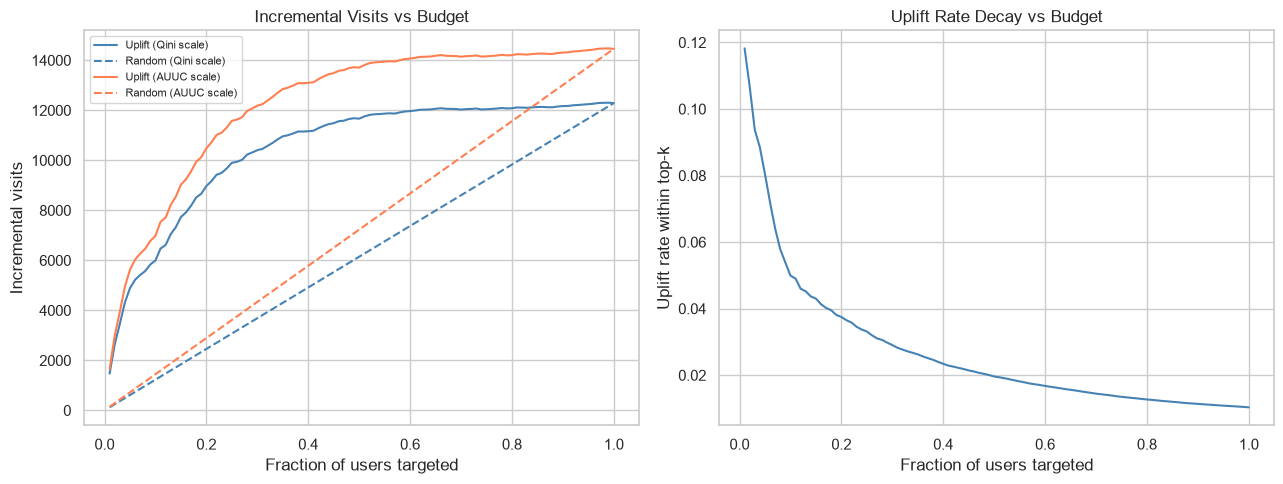

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

x = results["fraction_targeted"]

# left: incremental visits, both scales vs random baselines
axes[0].plot(x, results["incremental_qini"], color="steelblue", label="Uplift (Qini scale)")
axes[0].plot(x, results["random_qini"],      color="steelblue", linestyle="--", label="Random (Qini scale)")
axes[0].plot(x, results["incremental_auuc"], color="coral",     label="Uplift (AUUC scale)")
axes[0].plot(x, results["random_auuc"],      color="coral",     linestyle="--", label="Random (AUUC scale)")
axes[0].set_xlabel("Fraction of users targeted")
axes[0].set_ylabel("Incremental visits")
axes[0].set_title("Incremental Visits vs Budget")
axes[0].legend(fontsize=8)

# right: uplift rate decay within top-k
axes[1].plot(x, results["uplift_rate_topk"], color="steelblue")
axes[1].set_xlabel("Fraction of users targeted")
axes[1].set_ylabel("Uplift rate within top-k")
axes[1].set_title("Uplift Rate Decay vs Budget")

plt.tight_layout()
plt.savefig("../images/budget_simulation.png", dpi=150, bbox_inches="tight")
plt.show()

Both uplift curves rise steeply at low budgets and flatten as the ranking reaches lower-uplift users, while the random baselines increase linearly. The gap between uplift and random is largest at small budget fractions and narrows toward 100%. The AUUC curve sits consistently above the Qini curve by `~1/trmnt_ratio_topk`, but both cross their respective random baselines at approximately the same budget fraction. The right panel confirms strong diminishing returns: uplift rate drops from 11.8% at 1% budget to 5.0% at 10%.

## 5. Budget Savings

To capture 50%, 80%, and 95% of total possible incremental visits, what fraction of users needs to be targeted under uplift targeting vs random? The difference is the budget that can be saved while achieving the same outcome.

In [5]:
thresholds = [0.50, 0.80, 0.95]
rows_savings = []

for t in thresholds:
    target_qini = t * total_incremental_qini
    target_auuc = t * total_incremental_auuc

    frac_uplift_qini = results.loc[results["incremental_qini"] >= target_qini, "fraction_targeted"].min()
    frac_uplift_auuc = results.loc[results["incremental_auuc"] >= target_auuc, "fraction_targeted"].min()
    frac_random = t  # random is linear, so fraction needed = threshold

    rows_savings.append({
        "threshold":    f"{int(t*100)}% of ceiling",
        "uplift_qini":  frac_uplift_qini,
        "uplift_auuc":  frac_uplift_auuc,
        "random":       frac_random,
        "savings_qini": round(frac_random - frac_uplift_qini, 2),
        "savings_auuc": round(frac_random - frac_uplift_auuc, 2),
    })

savings = pd.DataFrame(rows_savings)
print(savings.to_string(index=False))

     threshold  uplift_qini  uplift_auuc  random  savings_qini  savings_auuc
50% of ceiling         0.11         0.11    0.50          0.39          0.39
80% of ceiling         0.25         0.25    0.80          0.55          0.55
95% of ceiling         0.49         0.51    0.95          0.46          0.44


Uplift targeting requires far less budget than random to reach the same incremental visit threshold. Savings are in percentage points (pp), the absolute difference between two budget fractions (e.g. 50% - 11% = 39pp). To capture 50% of the ceiling, only 11% of users need to be targeted vs 50% for random (39pp saving). For 80% of the ceiling, uplift targeting needs 25% of budget vs 80% for random (55pp saving). The 95% threshold requires 49% budget, a smaller saving because the Qini curve flattens and remaining persuadables are spread across a wide budget range.

`frac_uplift_qini` and `frac_uplift_auuc` are identical because both scales carry the same relative shape: numerator and denominator scale by the same factor (`~1/trmnt_ratio`), so the crossover fractions coincide.

## 6. Profit Framework

Sections 3-5 assumed a fixed budget. This section asks whether each user is individually worth targeting, given a cost per contact `c` and a value per incremental visit `v`.

Target user i if `uplift_i > c/v`. This threshold adapts to cost structure automatically, unlike top-X% targeting which requires a budget constraint upfront.

In [6]:
# v and c are assumptions since the Criteo dataset contains no revenue or cost data.
# What matters is the ratio c/v, not the absolute values.
# v=1 normalizes the value of one incremental visit; c is expressed as a fraction of v.
# In practice, v would be estimated revenue per incremental visit and c the cost per ad contact.
v = 1.0
c = 0.05  # baseline: contacting one user costs 5% of the value of one incremental visit

results["cost"]   = results["n_targeted"] * c
results["profit"] = results["incremental_auuc"] * v - results["cost"]

opt = results.loc[results["profit"].idxmax()]
print(f"Baseline c/v = {c}")
print(f"Optimal targeting fraction: {opt['fraction_targeted']:.0%}")
print(f"Peak profit:                {opt['profit']:.1f}")
print(f"Incremental visits at peak: {opt['incremental_auuc']:.0f}")
print(f"Users targeted:             {int(opt['n_targeted']):,}")

top10 = results[results["fraction_targeted"] <= 0.10][
    ["fraction_targeted", "n_targeted", "uplift_rate_topk", "incremental_auuc", "profit"]
].copy()
top10.columns = ["Fraction", "Users targeted", "Uplift rate", "Incr. visits (AUUC)", "Profit"]
top10["Fraction"]            = top10["Fraction"].map("{:.0%}".format)
top10["Uplift rate"]         = top10["Uplift rate"].map("{:.4f}".format)
top10["Incr. visits (AUUC)"] = top10["Incr. visits (AUUC)"].map("{:.1f}".format)
top10["Profit"]              = top10["Profit"].map("{:.1f}".format)
top10

Baseline c/v = 0.05
Optimal targeting fraction: 4%
Peak profit:                2150.5
Incremental visits at peak: 4946
Users targeted:             55,918


,Fraction,Users targeted,Uplift rate,Incr. visits (AUUC),Profit
0,1%,13979,0.1182,1652.3,953.4
1,2%,27959,0.1067,2983.9,1586.0
2,3%,41938,0.0937,3931.1,1834.2
3,4%,55918,0.0885,4946.4,2150.5
4,5%,69898,0.0804,5621.9,2127.0
5,6%,83877,0.0719,6030.6,1836.8
6,7%,97857,0.0641,6268.1,1375.3
7,8%,111836,0.0578,6467.0,875.2
8,9%,125816,0.0539,6777.7,486.9
9,10%,139796,0.0499,6977.4,-12.4


At c/v = 0.05, the optimal policy targets the top 4% of users (55,918 users), capturing 4,946 incremental visits at a peak profit of 2,150.5 normalized units. All values use v = 1 and c = 0.05 as abstract units, not real dollars; absolute profit scales linearly with v in deployment. For example, if v = $50 per incremental visit (c = $2.50 per contact), peak profit ≈ 2,150.5 × $50 = $107,525.

## 7. Profit Curve

Plot expected profit as a function of targeting fraction, sorted by predicted uplift descending:

```
profit(k) = k × uplift_rate_topk × v - k × c
```

The curve rises while each marginal user's predicted uplift exceeds c/v, and peaks where that condition no longer holds. This is the classic marginal revenue = marginal cost condition in uplift terms: keep targeting as long as `marginal_uplift > c/v`, stop when it falls below. The optimal fraction is therefore determined by where the ranking crosses the c/v threshold, not by a fixed budget.

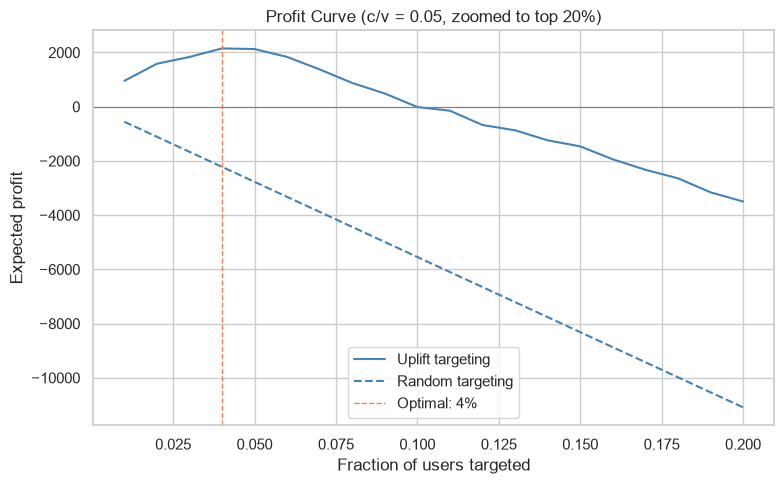

In [7]:
total_incremental_auuc = results["incremental_auuc"].iloc[-1]

results["random_profit"] = results["fraction_targeted"] * total_incremental_auuc * v - results["n_targeted"] * c

# zoom to first 20% where profit is meaningful
plot_data = results[results["fraction_targeted"] <= 0.20]

fig, ax = plt.subplots(figsize=(8, 5))
x = plot_data["fraction_targeted"]

ax.plot(x, plot_data["profit"],        color="steelblue", label="Uplift targeting")
ax.plot(x, plot_data["random_profit"], color="steelblue", linestyle="--", label="Random targeting")
ax.axvline(opt["fraction_targeted"], color="coral", linestyle="--", linewidth=1,
           label=f"Optimal: {opt['fraction_targeted']:.0%}")
ax.axhline(0, color="gray", linestyle="-", linewidth=0.8)
ax.set_xlabel("Fraction of users targeted")
ax.set_ylabel("Expected profit")
ax.set_title(f"Profit Curve (c/v = {c}, zoomed to top 20%)")
ax.legend()
plt.tight_layout()
plt.savefig("../images/profit_curve.png", dpi=150, bbox_inches="tight")
plt.show()

Beyond the peak, profit declines as lower-uplift users are added. The break-even point is between 9% and 10%: at 10%, the average within-group uplift rate (5.0%) barely falls below c/v = 0.05, tipping total profit to -12 units. Random targeting is unprofitable across the entire range at this c/v.

## 8. Sensitivity Analysis

The optimal targeting fraction depends on the c/v ratio. A lower c/v lowers the targeting bar, expanding the profitable user set; a higher c/v raises it, shrinking the set. Sweep c/v to see how the profit-maximizing threshold and peak profit respond to cost and value uncertainty.

 c/v  opt_fraction  peak_profit  incr_visits
0.01          0.25       8081.7        11577
0.02          0.18       4908.6         9941
0.03          0.05       3524.9         5622
0.05          0.04       2150.5         4946
0.08          0.02        747.2         2984
0.10          0.01        254.4         1652
0.15          0.01       -444.5         1652
0.20          0.01      -1143.5         1652


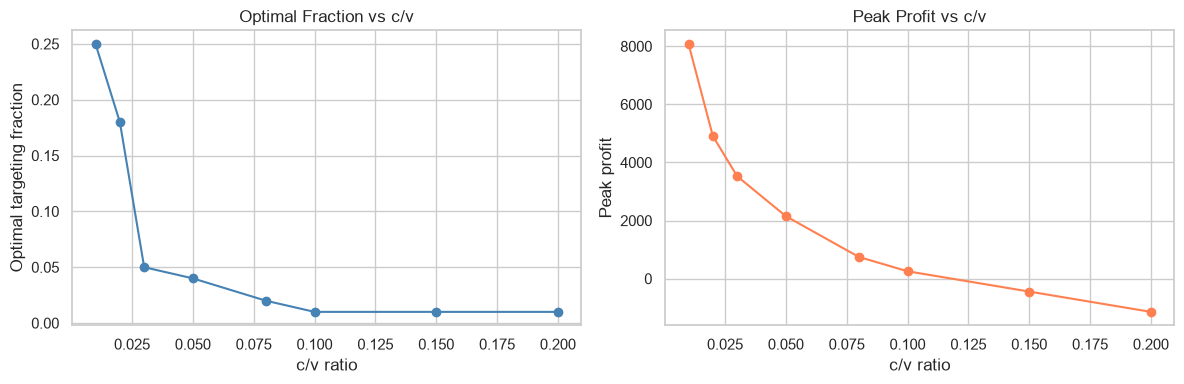

In [8]:
cv_values = [0.01, 0.02, 0.03, 0.05, 0.08, 0.10, 0.15, 0.20]
rows_sens = []

for cv in cv_values:
    profit_cv = results["incremental_auuc"] * v - results["n_targeted"] * cv
    opt_cv    = results.loc[profit_cv.idxmax()]
    rows_sens.append({
        "c/v":           cv,
        "opt_fraction":  opt_cv["fraction_targeted"],
        "peak_profit":   round(profit_cv.max(), 1),
        "incr_visits":   round(opt_cv["incremental_auuc"]),
    })

sens = pd.DataFrame(rows_sens)
print(sens.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(sens["c/v"], sens["opt_fraction"], marker="o", color="steelblue")
axes[0].set_xlabel("c/v ratio")
axes[0].set_ylabel("Optimal targeting fraction")
axes[0].set_title("Optimal Fraction vs c/v")

axes[1].plot(sens["c/v"], sens["peak_profit"], marker="o", color="coral")
axes[1].set_xlabel("c/v ratio")
axes[1].set_ylabel("Peak profit")
axes[1].set_title("Peak Profit vs c/v")

plt.tight_layout()
plt.savefig("../images/sensitivity_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

The optimal targeting fraction is highly sensitive to c/v: at c/v = 0.01 it expands to 25%; at c/v = 0.05 it collapses to 4%. At c/v = 0.15 and above, even the top 1% yields negative profit. Peak profit drops sharply with c/v: doubling from 0.05 to 0.10 cuts it by 88% (2,150 → 254 normalized units), making the targeting decision fragile to cost uncertainty.

## 9. Policy Comparison

Compare three targeting policies at a fixed reference budget of 10% of users:

| Policy | Description |
|---|---|
| Random | Target 10% of users randomly, no model |
| Top-10% | Target the top 10% by predicted uplift score |
| Threshold | Target all users where predicted uplift > c/v (budget self-selected) |

Random and Top-10% spend the full 10% budget. The threshold policy at c/v = 0.05 self-selects to its profit-maximizing 4% out of the 10% reference, spending 40% of the reference cost.

In [9]:
budget_fraction = 0.10

# Policy 1: Random — proportional share of total incremental visits
n_random = int(budget_fraction * N)
incr_random = budget_fraction * total_incremental_auuc
cost_random = n_random * c
profit_random = incr_random * v - cost_random

# Policy 2: Top-10% — best ranked users at the same budget
topk_row = results[results["fraction_targeted"] == budget_fraction].iloc[0]
incr_topk = topk_row["incremental_auuc"]
cost_topk = topk_row["n_targeted"] * c
profit_topk = incr_topk * v - cost_topk

# Policy 3: Threshold — profit-maximizing, self-selects budget at c/v = 0.05
incr_thresh = opt["incremental_auuc"]
cost_thresh = opt["n_targeted"] * c
profit_thresh = opt["profit"]

comparison = pd.DataFrame([
    {"Policy": "Random (10%)",            "Users targeted": f"{n_random:,}",                    "Fraction": "10%",                                    "Incr. visits": f"{incr_random:.0f}",  "Cost (norm.)": f"{cost_random:.0f}",  "Profit (norm.)": f"{profit_random:.0f}"},
    {"Policy": "Top-10%",                 "Users targeted": f"{int(topk_row['n_targeted']):,}", "Fraction": "10%",                                    "Incr. visits": f"{incr_topk:.0f}",    "Cost (norm.)": f"{cost_topk:.0f}",    "Profit (norm.)": f"{profit_topk:.0f}"},
    {"Policy": "Threshold (c/v = 0.05)",  "Users targeted": f"{int(opt['n_targeted']):,}",      "Fraction": f"{opt['fraction_targeted']:.0%}",         "Incr. visits": f"{incr_thresh:.0f}",  "Cost (norm.)": f"{cost_thresh:.0f}",  "Profit (norm.)": f"{profit_thresh:.0f}"},
])
comparison

,Policy,Users targeted,Fraction,Incr. visits,Cost (norm.),Profit (norm.)
0,Random (10%),"139,796",10%,1446,6990,-5544
1,Top-10%,"139,796",10%,6977,6990,-12
2,Threshold (c/v = 0.05),"55,918",4%,4946,2796,2151


At a 10% reference budget, random targeting captures 1,446 incremental visits at a loss of 5,544 normalized units. Top-10% improves to 6,977 visits but is still unprofitable (12 units lost), because at c/v = 0.05 the average uplift across the top 10% (5.0%) barely falls short of the contact cost. The threshold policy targets only 4% of users (4% out of the 10% reference), and is the only policy with positive profit (2,151 units), achieved by declining to spend on users below the cost-value bar.

## 10. Summary

**Budget efficiency**: At 1% budget, uplift targeting delivers 12x more incremental visits than random (1,474 vs 123, Qini scale). By 10%, the ratio narrows to 4.9x (5,994 vs 1,229).

**Budget savings**: Uplift targeting reaches the same incremental visit thresholds at a fraction of the budget required by random targeting (pp = percentage points, absolute difference between budget fractions).

| Threshold | Uplift budget | Random budget | Saving |
|---|---|---|---|
| 50% of ceiling | 11% | 50% | 39pp |
| 80% of ceiling | 25% | 80% | 55pp |
| 95% of ceiling | 49% | 95% | 46pp |

The saving narrows at 95% because the Qini curve flattens and remaining persuadables are spread thinly across the lower ranking.

**Profit-aware targeting**: At c/v = 0.05, the profit-maximizing policy targets the top 4% of users (55,918 users), capturing 4,946 incremental visits at a peak profit of 2,150 normalized units (scales linearly with v; e.g. if v = $50, peak profit ≈ $107,500). Profit stays positive up to 9% budget and turns negative at 10%. The optimal fraction is highly sensitive to c/v: it expands to 25% at c/v = 0.01 and turns negative for all users at c/v = 0.15.

**Policy comparison** (at 10% reference budget, c/v = 0.05):

| Policy | Fraction | Incr. visits | Profit (norm.) |
|---|---|---|---|
| Random | 10% | 1,446 | -5,544 |
| Top-10% | 10% | 6,977 | -12 |
| Threshold | 4% | 4,946 | +2,151 |

Even the top-ranked 10% barely fails to turn a profit at c/v = 0.05, because the average uplift across that group (5.0%) falls just short of the cost bar. The threshold policy avoids this by self-selecting to 4% budget and spending only on users whose expected return clears the cost.